# KOSPI VAR 기관 세분화

이 노트북은 KOSPI에 대해 기관을 세부 주체로 나눈 VAR 모형을 추정합니다.

- 분석기간: `2010-01-01 ~ 2025-12-31`
- 변수: `log_return`, `foreign_net_buy_ratio`, `securities_net_buy_ratio`, `insurance_net_buy_ratio`, `trust_net_buy_ratio`, `bank_net_buy_ratio`, `other_fin_net_buy_ratio`, `pension_net_buy_ratio`
- lag 탐색 범위: `1 ~ 5`
- 기본 lag 선택 기준: `BIC`
- 출력 결과: 정상성 검정, lag 선택, 안정성 확인, Granger 인과관계, IRF

기관 전체 순매수비율(`inst_net_buy_ratio`)은 세부 기관 순매수비율의 합과 중복되므로 본 노트북에서는 제외하고, 금융투자·보험·투신·은행·기타금융기관·연기금을 각각 별도 변수로 둡니다.
추가로 STEP 6에서는 환율과 금리의 일별 변동폭을 외생변수로 넣은 확장 VAR 결과도 확인합니다.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from statsmodels.tools.sm_exceptions import ValueWarning
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore", category=ValueWarning, module="statsmodels")

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


def find_kospi_csv() -> Path:
    candidate_paths = [
        Path("..") / "시계열 자료" / "kospi_clean.csv",
        Path.cwd().parent / "시계열 자료" / "kospi_clean.csv",
        Path("시계열 자료") / "kospi_clean.csv",
        Path.cwd() / "시계열 자료" / "kospi_clean.csv",
    ]
    for path in candidate_paths:
        resolved = path.resolve()
        if resolved.exists():
            return resolved

    matches = sorted(Path.cwd().rglob("kospi_clean.csv"))
    if not matches:
        raise FileNotFoundError("현재 작업 경로에서 kospi_clean.csv를 찾지 못했습니다.")
    return matches[0].resolve()


data_path = find_kospi_csv()
kospi_raw = pd.read_csv(data_path, parse_dates=["date"]).sort_values("date").reset_index(drop=True)

print(f"불러온 파일: {data_path}")
print(f"원본 기간: {kospi_raw['date'].min().date()} ~ {kospi_raw['date'].max().date()} / 행 수={len(kospi_raw):,}")
kospi_raw.head()


불러온 파일: C:\Users\sampo\OneDrive\바탕 화면\DART\레포트\Foreign_and_Institutional_Report\시계열 자료\kospi_clean.csv
원본 기간: 2008-12-30 ~ 2026-02-27 / 행 수=4,231


,market,date,open_index,high_index,low_index,close_index,return_pct,volume,turnover,krx_mkt_cap,...,n_unchanged,foreign_net_buy_ratio,inst_net_buy_ratio,personal_net_buy_ratio,securities_net_buy_ratio,insurance_net_buy_ratio,trust_net_buy_ratio,bank_net_buy_ratio,other_fin_net_buy_ratio,pension_net_buy_ratio
0,KOSPI,2008-12-30,1124.60,1144.24,1121.32,1124.47,0.62,357558060,3268892629610,576887540000000,...,118,0.058643,0.077002,-0.148499,0.000776,-0.002862,0.070745,-0.017593,-0.003447,0.027378
1,KOSPI,2009-01-02,1132.87,1157.40,1118.84,1157.40,2.93,340514581,4042808658950,593842360000000,...,86,0.015915,0.015577,-0.038942,0.005870,0.014542,-0.001309,-0.000388,-0.000025,0.001725
2,KOSPI,2009-01-05,1180.98,1185.22,1166.66,1173.57,1.40,414485922,5288134217010,602228320000000,...,109,0.063189,-0.023697,-0.047520,0.013760,0.011445,-0.046433,0.004016,0.001314,-0.006132
3,KOSPI,2009-01-06,1183.52,1203.59,1179.94,1194.28,1.76,443917919,5608350755670,613176993000000,...,94,0.065677,0.063959,-0.133970,0.006697,0.003870,0.057313,0.002158,0.000792,-0.010777
4,KOSPI,2009-01-07,1198.85,1228.56,1195.20,1228.17,2.84,568288212,7650295265290,630919917000000,...,103,0.073283,-0.002311,-0.076952,0.004770,0.005692,-0.010336,0.000907,0.000328,-0.002487


In [2]:
institution_detail_map = {
    "securities_net_buy_ratio": "금융투자",
    "insurance_net_buy_ratio": "보험",
    "trust_net_buy_ratio": "투신",
    "bank_net_buy_ratio": "은행",
    "other_fin_net_buy_ratio": "기타금융기관",
    "pension_net_buy_ratio": "연기금",
}

kospi = kospi_raw.copy()
kospi["log_return"] = np.log(kospi["close_index"]).diff()

var_columns = ["log_return", "foreign_net_buy_ratio", *institution_detail_map.keys()]
analysis = kospi[(kospi["date"] >= "2010-01-01") & (kospi["date"] <= "2025-12-31")].copy()
var_data = analysis[["date", *var_columns]].dropna().reset_index(drop=True)
endog = var_data[var_columns].copy()

variable_info = pd.DataFrame(
    [
        {"변수명": "log_return", "설명": "KOSPI 로그수익률"},
        {"변수명": "foreign_net_buy_ratio", "설명": "외국인 순매수비율"},
        *[
            {"변수명": col, "설명": f"{label} 순매수비율"}
            for col, label in institution_detail_map.items()
        ],
    ]
)

print(f"VAR 분석기간: {var_data['date'].min().date()} ~ {var_data['date'].max().date()} / 행 수={len(var_data):,}")
display(variable_info)
display(var_data.head())
display(endog.describe().T.round(6))


VAR 분석기간: 2010-01-04 ~ 2025-12-30 / 행 수=3,939


,변수명,설명
0,log_return,KOSPI 로그수익률
1,foreign_net_buy_ratio,외국인 순매수비율
2,securities_net_buy_ratio,금융투자 순매수비율
3,insurance_net_buy_ratio,보험 순매수비율
4,trust_net_buy_ratio,투신 순매수비율
5,bank_net_buy_ratio,은행 순매수비율
6,other_fin_net_buy_ratio,기타금융기관 순매수비율
7,pension_net_buy_ratio,연기금 순매수비율


,date,log_return,foreign_net_buy_ratio,securities_net_buy_ratio,insurance_net_buy_ratio,trust_net_buy_ratio,bank_net_buy_ratio,other_fin_net_buy_ratio,pension_net_buy_ratio
0,2010-01-04,0.007914,0.054762,-0.001224,0.012406,-0.003567,0.001777,-0.000139,-0.000779
1,2010-01-05,-0.003260,0.057407,-0.002129,0.000219,-0.011967,0.001540,0.000036,-0.008560
2,2010-01-06,0.008657,0.054936,0.005400,-0.003884,-0.009151,0.001267,-0.000873,-0.000899
3,2010-01-07,-0.012908,0.029384,0.004168,-0.008130,-0.005932,0.001433,0.001604,-0.005110
4,2010-01-08,0.006991,0.008541,0.000439,0.001209,-0.011332,-0.005389,0.001764,0.004249


,count,mean,std,min,25%,50%,75%,max
log_return,3939.0,0.000233,0.010791,-0.091761,-0.004975,0.000482,0.006131,0.082513
foreign_net_buy_ratio,3939.0,0.001013,0.043578,-0.199525,-0.023578,0.000710,0.026488,0.240183
securities_net_buy_ratio,3939.0,0.001672,0.028181,-0.153798,-0.011398,0.000719,0.014328,0.132413
insurance_net_buy_ratio,3939.0,-0.000024,0.007660,-0.096569,-0.002547,-0.000467,0.001762,0.250576
trust_net_buy_ratio,3939.0,-0.002701,0.013445,-0.096859,-0.007012,-0.001520,0.003106,0.067130
bank_net_buy_ratio,3939.0,-0.000835,0.007501,-0.197258,-0.000976,-0.000129,0.000353,0.078528
other_fin_net_buy_ratio,3939.0,-0.000227,0.002559,-0.054819,-0.000488,-0.000059,0.000316,0.045845
pension_net_buy_ratio,3939.0,0.003214,0.011693,-0.068766,-0.003416,0.001853,0.008155,0.086780


## STEP 1. 정상성 확인

모든 VAR 변수에 대해 ADF 검정으로 정상성을 확인합니다.

In [3]:
stationarity_records = []

for col in endog.columns:
    test_stat, p_value, used_lag, nobs, *_ = adfuller(endog[col], autolag="AIC")
    stationarity_records.append(
        {
            "변수": col,
            "설명": variable_info.set_index("변수명").loc[col, "설명"],
            "ADF 통계량": test_stat,
            "p-value": p_value,
            "사용 lag": used_lag,
            "관측치 수": nobs,
            "5% 유의수준 정상성": p_value < 0.05,
        }
    )

stationarity_table = pd.DataFrame(stationarity_records)
display(stationarity_table.round(6))


,변수,설명,ADF 통계량,p-value,사용 lag,관측치 수,5% 유의수준 정상성
0,log_return,KOSPI 로그수익률,-23.556235,0.0,6,3932,True
1,foreign_net_buy_ratio,외국인 순매수비율,-14.799805,0.0,7,3931,True
2,securities_net_buy_ratio,금융투자 순매수비율,-12.123554,0.0,19,3919,True
3,insurance_net_buy_ratio,보험 순매수비율,-8.497207,0.0,30,3908,True
4,trust_net_buy_ratio,투신 순매수비율,-9.917669,0.0,17,3921,True
5,bank_net_buy_ratio,은행 순매수비율,-41.926727,0.0,1,3937,True
6,other_fin_net_buy_ratio,기타금융기관 순매수비율,-19.711126,0.0,7,3931,True
7,pension_net_buy_ratio,연기금 순매수비율,-7.125919,0.0,21,3917,True


## STEP 2. lag 선택

`1`부터 `5`까지 비교한 뒤 기본적으로 `BIC` 최소값을 선택합니다. 필요하면 아래 `selected_lag_rule`을 `"AIC"`로 바꿔 비교할 수 있습니다.

In [4]:
var_model = VAR(endog)

lag_records = []
for p_lag in range(1, 6):
    fitted = var_model.fit(p_lag)
    lag_records.append(
        {
            "lag": p_lag,
            "AIC": fitted.aic,
            "BIC": fitted.bic,
            "HQIC": fitted.hqic,
            "FPE": fitted.fpe,
        }
    )

lag_table = pd.DataFrame(lag_records).set_index("lag")
display(lag_table.round(6))

aic_lag = int(lag_table["AIC"].idxmin())
bic_lag = int(lag_table["BIC"].idxmin())
selected_lag_rule = "BIC"
selected_lag = int(lag_table[selected_lag_rule].idxmin())

print(f"AIC 기준 선택 lag: {aic_lag}")
print(f"BIC 기준 선택 lag: {bic_lag}")
print(f"최종 사용 lag: {selected_lag} ({selected_lag_rule} 기준)")


,AIC,BIC,HQIC,FPE
lag,,,,
1,-73.126605,-73.011814,-73.085882,0.0
2,-73.234531,-73.017657,-73.157593,0.0
3,-73.259998,-72.940998,-73.146828,0.0
4,-73.260199,-72.839029,-73.110780,0.0
5,-73.262185,-72.738801,-73.076502,0.0


AIC 기준 선택 lag: 5
BIC 기준 선택 lag: 2
최종 사용 lag: 2 (BIC 기준)


## STEP 3. VAR 추정 및 안정성 확인

선택된 lag로 VAR을 적합하고 안정성을 확인합니다. `statsmodels` 기준으로 roots modulus가 모두 `1`보다 크면 안정적입니다.

In [5]:
var_results = var_model.fit(selected_lag)

stability_table = (
    pd.DataFrame({"root modulus": np.abs(var_results.roots)})
    .sort_values("root modulus")
    .reset_index(drop=True)
)

print(f"안정적 VAR 여부: {var_results.is_stable()}")
display(stability_table.round(6))
var_results.summary()


안정적 VAR 여부: True


,root modulus
0,1.377224
1,1.625892
2,1.853734
3,2.209512
4,2.634502
5,3.010865
6,3.653371
7,3.653371
8,4.015060
9,4.600240


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 30, Mar, 2026
Time:                     16:32:28
--------------------------------------------------------------------
No. of Equations:         8.00000    BIC:                   -73.0177
Nobs:                     3937.00    HQIC:                  -73.1576
Log likelihood:           99607.3    FPE:                1.56548e-32
AIC:                     -73.2345    Det(Omega_mle):     1.51244e-32
--------------------------------------------------------------------
Results for equation log_return
                                 coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------------------
const                               0.000309         0.000189            1.632           0.103
L1.log_return                      -0.018935         0.021115           -0.897           0.370

## STEP 4. Granger 인과관계 검정

외국인과 각 세부 기관 주체에 대해 `순매수비율 -> 수익률`, `수익률 -> 순매수비율` 방향을 각각 검정합니다.

In [6]:
entity_label_map = {"foreign_net_buy_ratio": "외국인", **institution_detail_map}

granger_specs = [
    ("log_return", ["foreign_net_buy_ratio"], "외국인 -> 수익률"),
    ("foreign_net_buy_ratio", ["log_return"], "수익률 -> 외국인"),
]
granger_specs.extend(
    [
        ("log_return", [col], f"{label} -> 수익률")
        for col, label in institution_detail_map.items()
    ]
)
granger_specs.extend(
    [
        (col, ["log_return"], f"수익률 -> {label}")
        for col, label in institution_detail_map.items()
    ]
)

granger_records = []
for caused, causing, label in granger_specs:
    test = var_results.test_causality(caused=caused, causing=causing, kind="f")
    granger_records.append(
        {
            "검정": label,
            "종속 변수": caused,
            "종속 변수 설명": entity_label_map.get(caused, caused if caused == "log_return" else caused),
            "원인 변수": ", ".join(causing),
            "F 통계량": test.test_statistic,
            "p-value": test.pvalue,
            "자유도": str(test.df),
            "5% 유의": test.pvalue < 0.05,
        }
    )

granger_table = pd.DataFrame(granger_records)
display(granger_table.round(6))


,검정,종속 변수,종속 변수 설명,원인 변수,F 통계량,p-value,자유도,5% 유의
0,외국인 -> 수익률,log_return,log_return,foreign_net_buy_ratio,1.056424,0.347709,"(2, 31360)",False
1,수익률 -> 외국인,foreign_net_buy_ratio,외국인,log_return,7.166966,0.000773,"(2, 31360)",True
2,금융투자 -> 수익률,log_return,log_return,securities_net_buy_ratio,1.034405,0.355450,"(2, 31360)",False
3,보험 -> 수익률,log_return,log_return,insurance_net_buy_ratio,0.451141,0.636905,"(2, 31360)",False
4,투신 -> 수익률,log_return,log_return,trust_net_buy_ratio,1.444415,0.235900,"(2, 31360)",False
5,은행 -> 수익률,log_return,log_return,bank_net_buy_ratio,0.978667,0.375823,"(2, 31360)",False
6,기타금융기관 -> 수익률,log_return,log_return,other_fin_net_buy_ratio,0.186063,0.830223,"(2, 31360)",False
7,연기금 -> 수익률,log_return,log_return,pension_net_buy_ratio,0.148448,0.862045,"(2, 31360)",False
8,수익률 -> 금융투자,securities_net_buy_ratio,금융투자,log_return,19.721689,0.000000,"(2, 31360)",True
9,수익률 -> 보험,insurance_net_buy_ratio,보험,log_return,7.696290,0.000455,"(2, 31360)",True


## STEP 5. IRF

세부 기관별 shock이 수익률에 미치는 반응과 수익률 shock에 대한 세부 기관별 반응을 함께 시각화합니다. 기본 설정은 `orth=False`입니다.

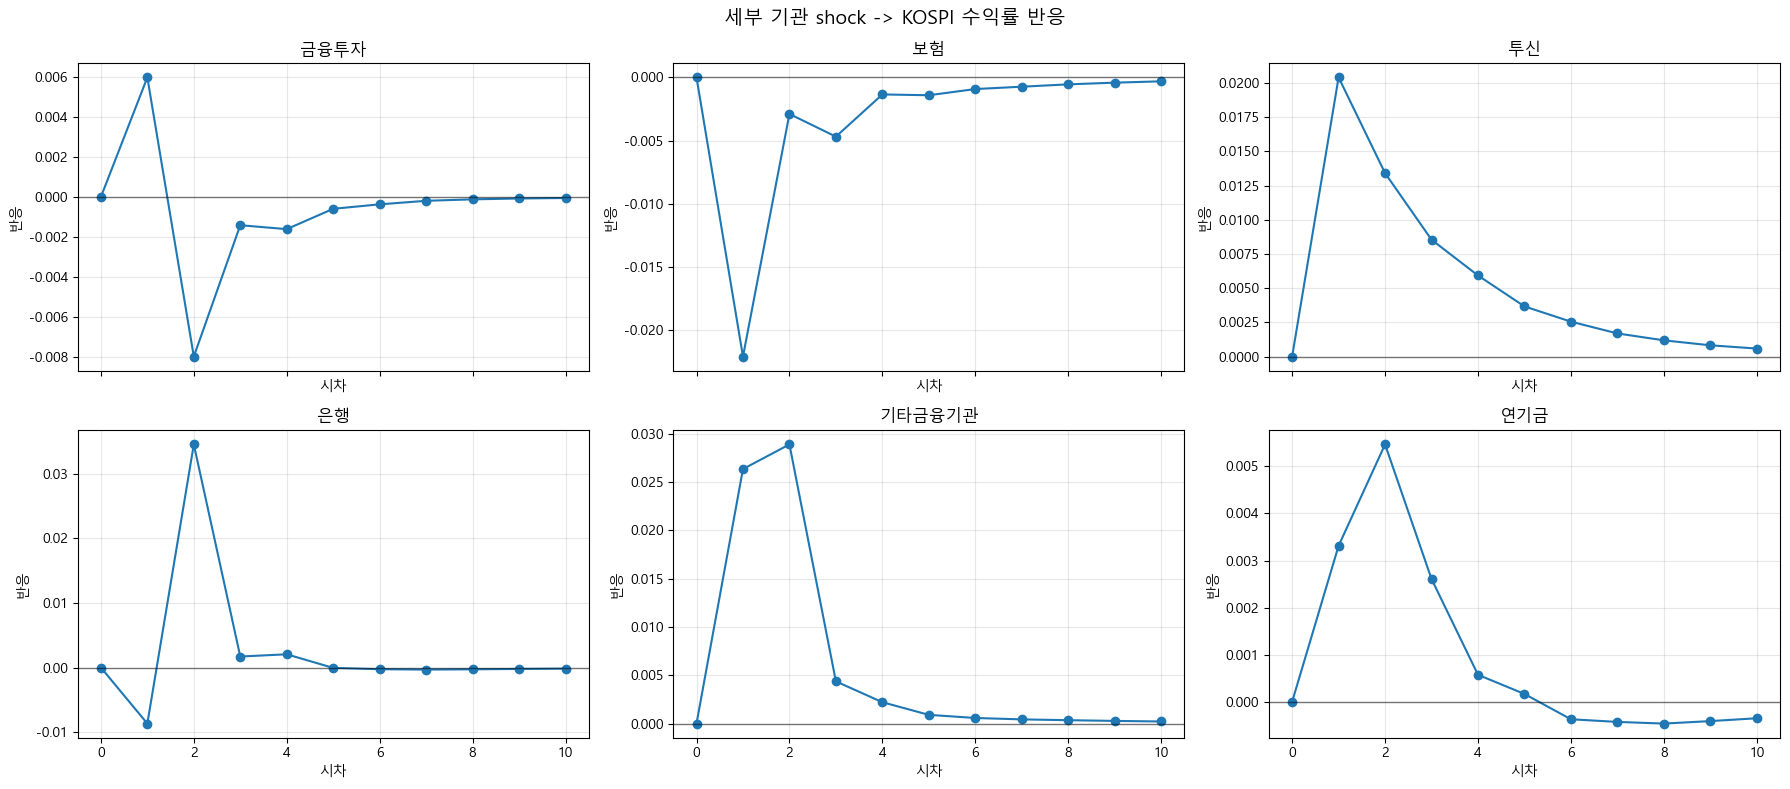

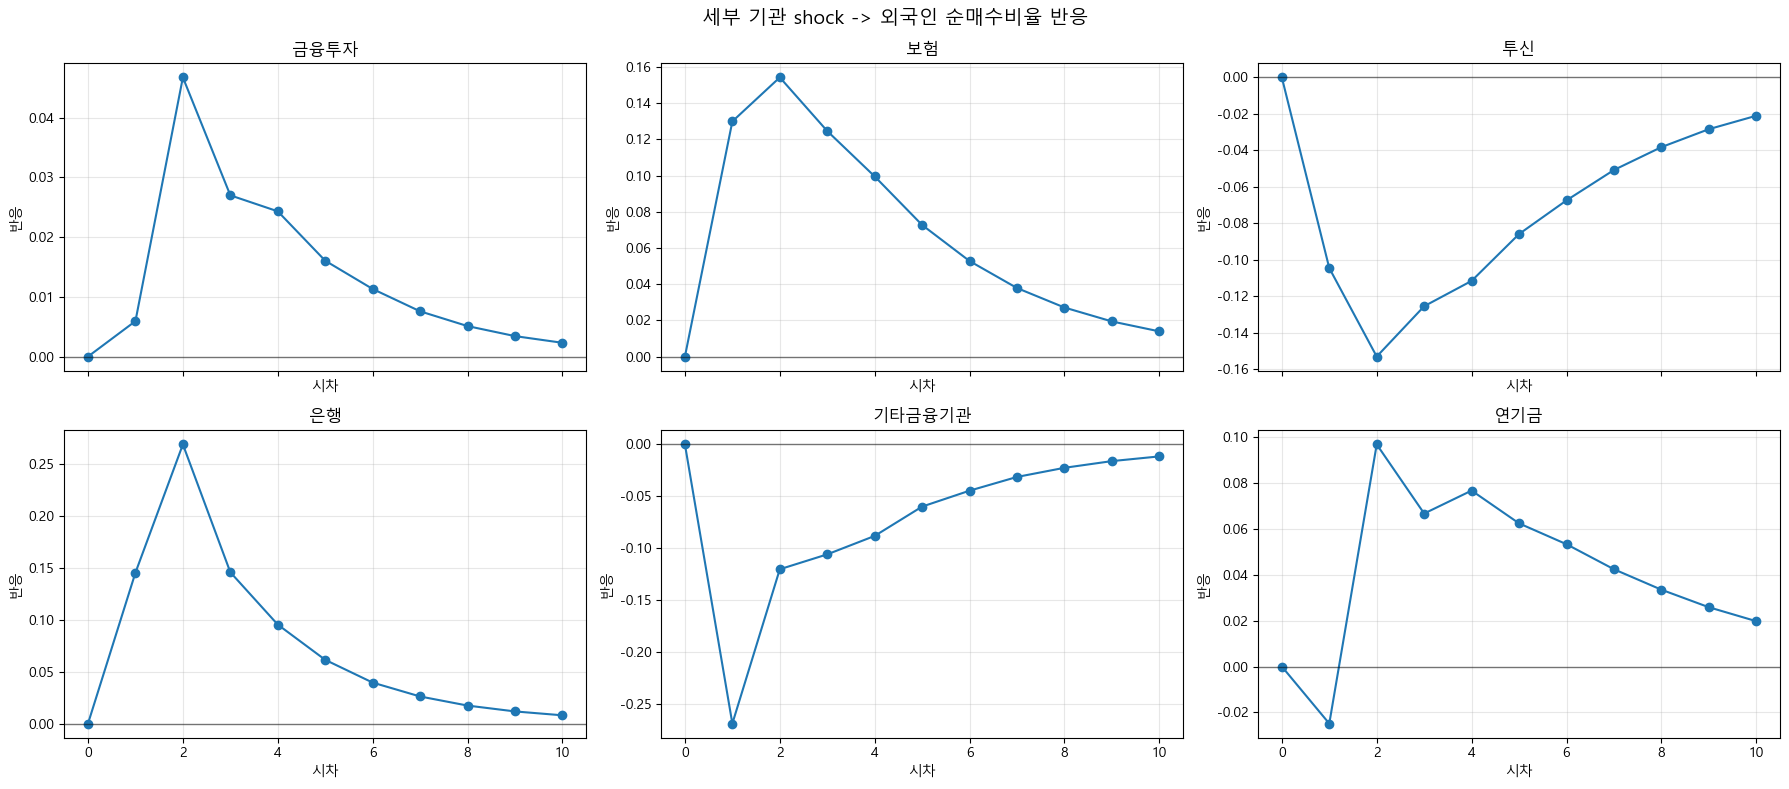

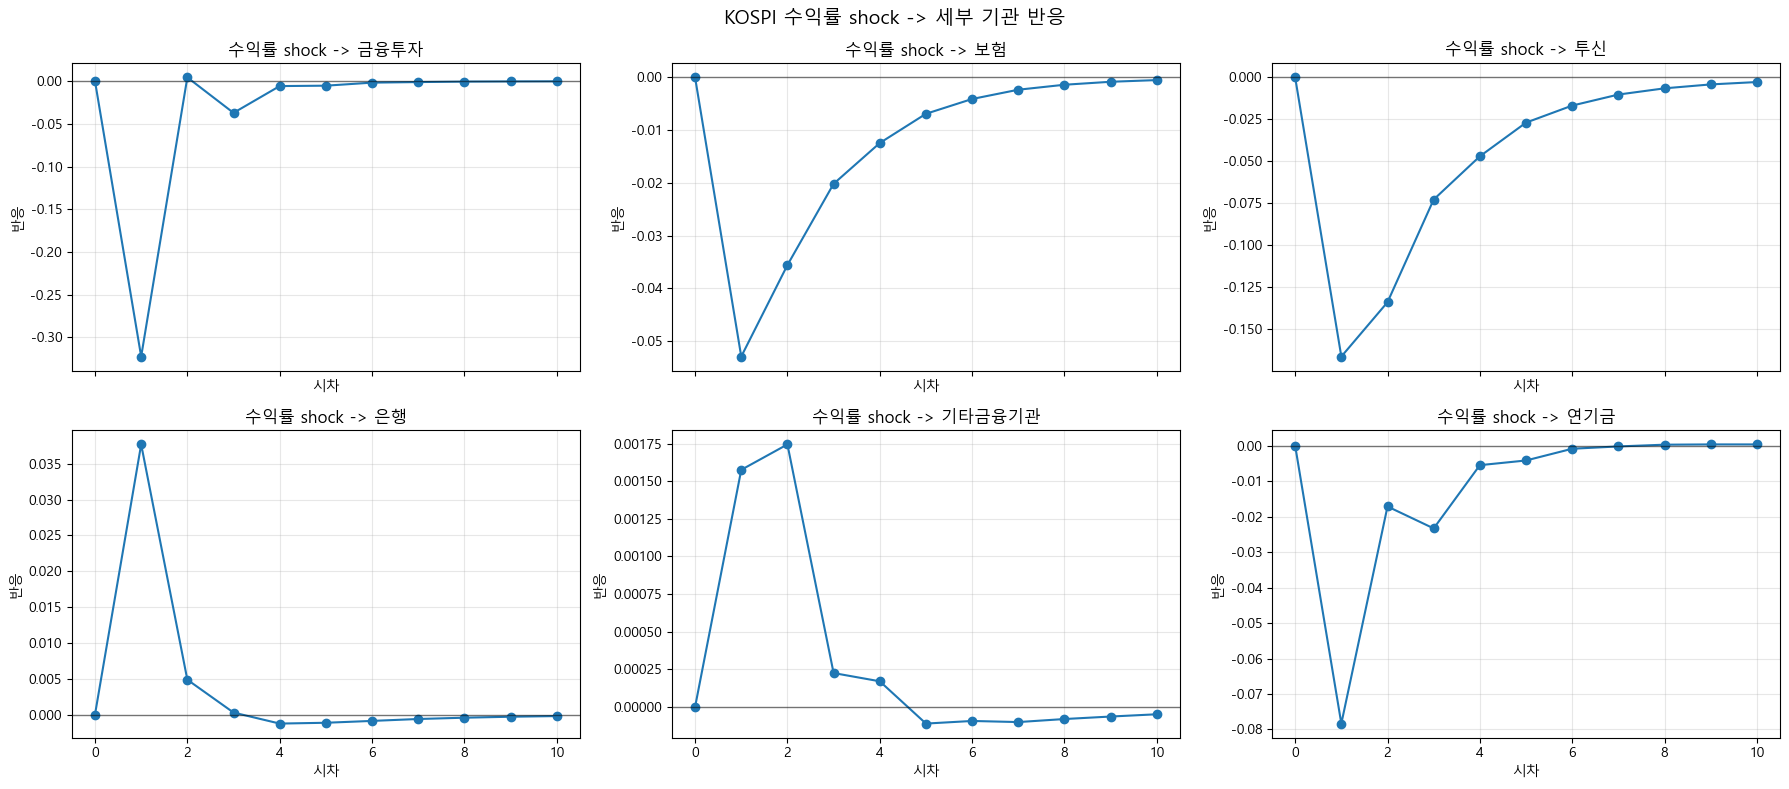

In [7]:
irf_horizon = 10
irf = var_results.irf(irf_horizon)

response_idx = {name: i for i, name in enumerate(endog.columns)}
periods = np.arange(irf_horizon + 1)
institution_cols = list(institution_detail_map.keys())
irf_impulse_label_map = {"foreign_net_buy_ratio": "외국인", **institution_detail_map}
irf_response_label_map = {
    "log_return": "KOSPI 수익률",
    "foreign_net_buy_ratio": "외국인",
    **institution_detail_map,
}

significant_to_return = granger_table.loc[
    (granger_table["종속 변수"] == "log_return") & (granger_table["5% 유의"]),
    "원인 변수",
].tolist()
significant_institution_to_foreign = granger_table.loc[
    (granger_table["종속 변수"] == "foreign_net_buy_ratio")
    & (granger_table["원인 변수"] != "log_return")
    & (granger_table["5% 유의"]),
    "원인 변수",
].tolist()
significant_from_return = granger_table.loc[
    (granger_table["원인 변수"] == "log_return") & (granger_table["5% 유의"]),
    "종속 변수",
].tolist()


def plot_irf_grid(response_var: str, impulse_vars: list[str], title: str, empty_message: str) -> None:
    if not impulse_vars:
        print(empty_message)
        return

    ncols = 3
    nrows = int(np.ceil(len(impulse_vars) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows), sharex=True)
    axes = np.atleast_1d(axes).flatten()

    for ax, impulse_var in zip(axes, impulse_vars):
        response_series = irf.irfs[
            :,
            response_idx[response_var],
            response_idx[impulse_var],
        ]
        ax.plot(periods, response_series, marker="o")
        ax.axhline(0, color="black", linewidth=1, alpha=0.5)
        ax.set_title(irf_impulse_label_map.get(impulse_var, impulse_var))
        ax.set_xlabel("시차")
        ax.set_ylabel("반응")
        ax.grid(alpha=0.3)

    for ax in axes[len(impulse_vars):]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


def plot_return_shock_responses(response_vars: list[str], title: str, empty_message: str) -> None:
    if not response_vars:
        print(empty_message)
        return

    ncols = 3
    nrows = int(np.ceil(len(response_vars) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows), sharex=True)
    axes = np.atleast_1d(axes).flatten()

    for ax, response_var in zip(axes, response_vars):
        response_series = irf.irfs[
            :,
            response_idx[response_var],
            response_idx["log_return"],
        ]
        ax.plot(periods, response_series, marker="o")
        ax.axhline(0, color="black", linewidth=1, alpha=0.5)
        ax.set_title(f"수익률 shock -> {irf_response_label_map.get(response_var, response_var)}")
        ax.set_xlabel("시차")
        ax.set_ylabel("반응")
        ax.grid(alpha=0.3)

    for ax in axes[len(response_vars):]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


print("Granger 인과관계가 5% 유의했던 방향만 IRF로 시각화합니다.")

plot_irf_grid(
    response_var="log_return",
    impulse_vars=significant_to_return,
    title="Granger 유의 관계만: KOSPI 수익률 반응",
    empty_message="유의한 '원인 변수 -> KOSPI 수익률' 관계가 없어 해당 IRF는 생략합니다.",
)

plot_irf_grid(
    response_var="foreign_net_buy_ratio",
    impulse_vars=significant_institution_to_foreign,
    title="Granger 유의 관계만: 외국인 순매수비율 반응",
    empty_message="유의한 '세부 기관 -> 외국인 순매수비율' 관계가 없어 해당 IRF는 생략합니다.",
)

plot_return_shock_responses(
    response_vars=significant_from_return,
    title="Granger 유의 관계만: KOSPI 수익률 shock -> 반응 변수",
    empty_message="유의한 'KOSPI 수익률 -> 반응 변수' 관계가 없어 해당 IRF는 생략합니다.",
)


## STEP 6. 환율·금리 변동폭을 외생변수로 넣은 확장 VAR

기본 세부기관 VAR은 그대로 두고, `usdkrw`와 `korea_3y_yield`의 일별 변동폭(1차 차분)을 외생변수로 추가한 확장 VAR도 함께 봅니다.

- 환율 변동폭: `usdkrw_change = usdkrw.diff()`
- 금리 변동폭: `korea_3y_yield_change = korea_3y_yield.diff()`
- 외생변수는 IRF의 impulse 대상이 아니라 각 내생변수 방정식의 공통 설명변수로 해석합니다.

In [8]:
analysis_exog = analysis.copy()
analysis_exog["usdkrw_change"] = analysis_exog["usdkrw"].diff()
analysis_exog["korea_3y_yield_change"] = analysis_exog["korea_3y_yield"].diff()

varx_data = analysis_exog[
    ["date", *var_columns, "usdkrw_change", "korea_3y_yield_change"]
].dropna().reset_index(drop=True)

endog_varx = varx_data[var_columns].copy()
exog_varx = varx_data[["usdkrw_change", "korea_3y_yield_change"]].copy()

print(
    f"외생변수 포함 VAR 분석기간: "
    f"{varx_data['date'].min().date()} ~ {varx_data['date'].max().date()} / 행 수={len(varx_data):,}"
)
display(varx_data.head())
display(exog_varx.describe().T.round(6))

exog_stationarity_records = []
for col in exog_varx.columns:
    test_stat, p_value, used_lag, nobs, *_ = adfuller(exog_varx[col], autolag="AIC")
    exog_stationarity_records.append(
        {
            "변수": col,
            "ADF 통계량": test_stat,
            "p-value": p_value,
            "사용 lag": used_lag,
            "관측치 수": nobs,
            "5% 유의수준 정상성": p_value < 0.05,
        }
    )

exog_stationarity_table = pd.DataFrame(exog_stationarity_records)
display(exog_stationarity_table.round(6))


외생변수 포함 VAR 분석기간: 2010-01-05 ~ 2025-12-30 / 행 수=3,938


,date,log_return,foreign_net_buy_ratio,securities_net_buy_ratio,insurance_net_buy_ratio,trust_net_buy_ratio,bank_net_buy_ratio,other_fin_net_buy_ratio,pension_net_buy_ratio,usdkrw_change,korea_3y_yield_change
0,2010-01-05,-0.003260,0.057407,-0.002129,0.000219,-0.011967,0.001540,0.000036,-0.008560,-11.4,-0.08
1,2010-01-06,0.008657,0.054936,0.005400,-0.003884,-0.009151,0.001267,-0.000873,-0.000899,-11.9,0.07
2,2010-01-07,-0.012908,0.029384,0.004168,-0.008130,-0.005932,0.001433,0.001604,-0.005110,-6.1,-0.11
3,2010-01-08,0.006991,0.008541,0.000439,0.001209,-0.011332,-0.005389,0.001764,0.004249,-5.0,0.04
4,2010-01-11,-0.000673,-0.022938,0.004162,0.009949,0.005501,-0.002012,0.001021,0.005825,-0.3,-0.09


,count,mean,std,min,25%,50%,75%,max
usdkrw_change,3938.0,0.067623,6.057788,-36.000,-3.400,0.1,3.375,43.100
korea_3y_yield_change,3938.0,-0.000378,0.037878,-0.268,-0.019,0.0,0.016,0.349


,변수,ADF 통계량,p-value,사용 lag,관측치 수,5% 유의수준 정상성
0,usdkrw_change,-13.535918,0.0,20,3917,True
1,korea_3y_yield_change,-12.657430,0.0,21,3916,True


In [9]:
varx_model = VAR(endog_varx, exog=exog_varx)

varx_lag_records = []
for p_lag in range(1, 6):
    fitted = varx_model.fit(p_lag)
    varx_lag_records.append(
        {
            "lag": p_lag,
            "AIC": fitted.aic,
            "BIC": fitted.bic,
            "HQIC": fitted.hqic,
            "FPE": fitted.fpe,
        }
    )

varx_lag_table = pd.DataFrame(varx_lag_records).set_index("lag")
display(varx_lag_table.round(6))

varx_selected_lag_rule = selected_lag_rule
varx_selected_lag = int(varx_lag_table[varx_selected_lag_rule].idxmin())

print(f"외생변수 포함 VAR의 최종 사용 lag: {varx_selected_lag} ({varx_selected_lag_rule} 기준)")


,AIC,BIC,HQIC,FPE
lag,,,,
1,-73.131274,-72.990944,-73.081491,0.0
2,-73.237509,-72.995069,-73.151500,0.0
3,-73.263624,-72.919031,-73.141373,0.0
4,-73.263183,-72.816392,-73.104673,0.0
5,-73.265514,-72.716482,-73.070729,0.0


외생변수 포함 VAR의 최종 사용 lag: 2 (BIC 기준)


In [10]:
varx_results = varx_model.fit(varx_selected_lag)

varx_stability_table = (
    pd.DataFrame({"root modulus": np.abs(varx_results.roots)})
    .sort_values("root modulus")
    .reset_index(drop=True)
)

print(f"안정적 VAR 여부(외생변수 포함): {varx_results.is_stable()}")
display(varx_stability_table.round(6))
varx_results.summary()


안정적 VAR 여부(외생변수 포함): True


,root modulus
0,1.377670
1,1.627392
2,1.862340
3,2.216928
4,2.624481
5,3.015555
6,3.687991
7,3.687991
8,4.059878
9,4.586998


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 30, Mar, 2026
Time:                     16:32:31
--------------------------------------------------------------------
No. of Equations:         8.00000    BIC:                   -72.9951
Nobs:                     3936.00    HQIC:                  -73.1515
Log likelihood:           99603.9    FPE:                1.56083e-32
AIC:                     -73.2375    Det(Omega_mle):     1.50184e-32
--------------------------------------------------------------------
Results for equation log_return
                                 coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------------------
const                               0.000307         0.000189            1.621           0.105
usdkrw_change                      -0.000016         0.000033           -0.504           0.615

In [11]:
varx_target_names = list(endog_varx.columns)
varx_target_label_map = {
    "log_return": "KOSPI 로그수익률",
    "foreign_net_buy_ratio": "외국인 순매수비율",
    **{col: f"{label} 순매수비율" for col, label in institution_detail_map.items()},
}
varx_param_names = ["const", *list(exog_varx.columns)] + [
    f"L{lag}.{name}"
    for lag in range(1, varx_selected_lag + 1)
    for name in varx_target_names
]

varx_raw_params = pd.DataFrame(
    np.asarray(varx_results._results.params),
    index=varx_param_names,
    columns=varx_target_names,
)
varx_raw_pvalues = pd.DataFrame(
    np.asarray(varx_results._results.pvalues),
    index=varx_param_names,
    columns=varx_target_names,
)

exog_effect_records = []
for exog_name in exog_varx.columns:
    for target in varx_target_names:
        exog_effect_records.append(
            {
                "외생 변수": exog_name,
                "종속 변수": target,
                "종속 변수 설명": varx_target_label_map[target],
                "계수": varx_raw_params.loc[exog_name, target],
                "p-value": varx_raw_pvalues.loc[exog_name, target],
                "5% 유의": varx_raw_pvalues.loc[exog_name, target] < 0.05,
            }
        )

exog_effect_table = pd.DataFrame(exog_effect_records)
model_comparison_table = pd.DataFrame(
    [
        {
            "모형": "기본 VAR",
            "관측치 수": len(var_data),
            "lag": selected_lag,
            "AIC": var_results.aic,
            "BIC": var_results.bic,
            "안정적": var_results.is_stable(),
        },
        {
            "모형": "외생변수 포함 VAR",
            "관측치 수": len(varx_data),
            "lag": varx_selected_lag,
            "AIC": varx_results.aic,
            "BIC": varx_results.bic,
            "안정적": varx_results.is_stable(),
        },
    ]
)

print("외생변수 계수 요약")
display(exog_effect_table.round(6))

print("기본 VAR과 외생변수 포함 VAR 비교")
display(model_comparison_table.round(6))

print("5% 유의한 외생변수 효과")
display(exog_effect_table[exog_effect_table["5% 유의"]].round(6))


외생변수 계수 요약


,외생 변수,종속 변수,종속 변수 설명,계수,p-value,5% 유의
0,usdkrw_change,log_return,KOSPI 로그수익률,-0.000016,0.614505,False
1,usdkrw_change,foreign_net_buy_ratio,외국인 순매수비율,-0.000191,0.092402,False
2,usdkrw_change,securities_net_buy_ratio,금융투자 순매수비율,0.000041,0.613909,False
3,usdkrw_change,insurance_net_buy_ratio,보험 순매수비율,-0.000003,0.884765,False
4,usdkrw_change,trust_net_buy_ratio,투신 순매수비율,0.000021,0.508685,False
5,usdkrw_change,bank_net_buy_ratio,은행 순매수비율,-0.000002,0.946077,False
6,usdkrw_change,other_fin_net_buy_ratio,기타금융기관 순매수비율,-0.000003,0.668392,False
7,usdkrw_change,pension_net_buy_ratio,연기금 순매수비율,-0.000054,0.086233,False
8,korea_3y_yield_change,log_return,KOSPI 로그수익률,0.010883,0.016898,True
9,korea_3y_yield_change,foreign_net_buy_ratio,외국인 순매수비율,0.031165,0.049905,True


기본 VAR과 외생변수 포함 VAR 비교


,모형,관측치 수,lag,AIC,BIC,안정적
0,기본 VAR,3939,2,-73.234531,-73.017657,True
1,외생변수 포함 VAR,3938,2,-73.237509,-72.995069,True


5% 유의한 외생변수 효과


,외생 변수,종속 변수,종속 변수 설명,계수,p-value,5% 유의
8,korea_3y_yield_change,log_return,KOSPI 로그수익률,0.010883,0.016898,True
9,korea_3y_yield_change,foreign_net_buy_ratio,외국인 순매수비율,0.031165,0.049905,True
10,korea_3y_yield_change,securities_net_buy_ratio,금융투자 순매수비율,-0.059123,0.000000,True


## STEP 7. 외생변수 포함 VAR의 Granger 인과관계와 IRF

확장 VAR(`varx_results`)에 대해서도 내생변수간 Granger 인과관계와 IRF를 확인합니다. 환율·금리 변화폭은 외생변수이므로 impulse 대상에서는 제외하고, 내생변수 반응을 중심으로 해석합니다.


In [ ]:

varx_entity_label_map = {
    "log_return": "KOSPI 로그수익률",
    "foreign_net_buy_ratio": "외국인 순매수비율",
    **{col: f"{label} 순매수비율" for col, label in institution_detail_map.items()},
}

varx_granger_specs = [
    ("log_return", ["foreign_net_buy_ratio"], "외국인 -> 수익률"),
    ("foreign_net_buy_ratio", ["log_return"], "수익률 -> 외국인"),
]
varx_granger_specs.extend(
    [
        ("log_return", [col], f"{label} -> 수익률")
        for col, label in institution_detail_map.items()
    ]
)
varx_granger_specs.extend(
    [
        (col, ["log_return"], f"수익률 -> {label}")
        for col, label in institution_detail_map.items()
    ]
)

varx_granger_records = []
for caused, causing, label in varx_granger_specs:
    test = varx_results.test_causality(caused=caused, causing=causing, kind="f")
    varx_granger_records.append(
        {
            "가설": label,
            "종속 변수": caused,
            "종속 변수 설명": varx_entity_label_map.get(caused, caused),
            "원인 변수": ", ".join(causing),
            "F 통계량": test.test_statistic,
            "p-value": test.pvalue,
            "자유도": str(test.df),
            "5% 유의": test.pvalue < 0.05,
        }
    )

varx_granger_table = pd.DataFrame(varx_granger_records)
print("외생변수 포함 VAR의 Granger 인과관계")
display(varx_granger_table.round(6))


In [ ]:

varx_irf_horizon = irf_horizon
varx_irf = varx_results.irf(varx_irf_horizon)

varx_response_idx = {name: i for i, name in enumerate(endog_varx.columns)}
varx_periods = np.arange(varx_irf_horizon + 1)
varx_institution_cols = list(institution_detail_map.keys())
varx_irf_impulse_label_map = {"foreign_net_buy_ratio": "외국인", **institution_detail_map}
varx_irf_response_label_map = {
    "log_return": "KOSPI 수익률",
    "foreign_net_buy_ratio": "외국인",
    **institution_detail_map,
}

varx_significant_to_return = varx_granger_table.loc[
    (varx_granger_table["종속 변수"] == "log_return") & (varx_granger_table["5% 유의"]),
    "원인 변수",
].tolist()
varx_significant_institution_to_foreign = varx_granger_table.loc[
    (varx_granger_table["종속 변수"] == "foreign_net_buy_ratio")
    & (varx_granger_table["원인 변수"] != "log_return")
    & (varx_granger_table["5% 유의"]),
    "원인 변수",
].tolist()
varx_significant_from_return = varx_granger_table.loc[
    (varx_granger_table["원인 변수"] == "log_return") & (varx_granger_table["5% 유의"]),
    "종속 변수",
].tolist()


def plot_varx_irf_grid(response_var: str, impulse_vars: list[str], title: str, empty_message: str) -> None:
    if not impulse_vars:
        print(empty_message)
        return

    ncols = 3
    nrows = int(np.ceil(len(impulse_vars) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows), sharex=True)
    axes = np.atleast_1d(axes).flatten()

    for ax, impulse_var in zip(axes, impulse_vars):
        response_series = varx_irf.irfs[
            :,
            varx_response_idx[response_var],
            varx_response_idx[impulse_var],
        ]
        ax.plot(varx_periods, response_series, marker="o")
        ax.axhline(0, color="black", linewidth=1, alpha=0.5)
        ax.set_title(varx_irf_impulse_label_map.get(impulse_var, impulse_var))
        ax.set_xlabel("시차")
        ax.set_ylabel("반응")
        ax.grid(alpha=0.3)

    for ax in axes[len(impulse_vars):]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


def plot_varx_return_shock_responses(response_vars: list[str], title: str, empty_message: str) -> None:
    if not response_vars:
        print(empty_message)
        return

    ncols = 3
    nrows = int(np.ceil(len(response_vars) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows), sharex=True)
    axes = np.atleast_1d(axes).flatten()

    for ax, response_var in zip(axes, response_vars):
        response_series = varx_irf.irfs[
            :,
            varx_response_idx[response_var],
            varx_response_idx["log_return"],
        ]
        ax.plot(varx_periods, response_series, marker="o")
        ax.axhline(0, color="black", linewidth=1, alpha=0.5)
        ax.set_title(f"수익률 shock -> {varx_irf_response_label_map.get(response_var, response_var)}")
        ax.set_xlabel("시차")
        ax.set_ylabel("반응")
        ax.grid(alpha=0.3)

    for ax in axes[len(response_vars):]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


print("외생변수 포함 VAR도 Granger 인과관계가 5% 유의했던 방향만 IRF로 시각화합니다.")

plot_varx_irf_grid(
    response_var="log_return",
    impulse_vars=varx_significant_to_return,
    title="외생변수 포함 VAR: Granger 유의 관계만 KOSPI 수익률 반응",
    empty_message="외생변수 포함 VAR에서 유의한 '원인 변수 -> KOSPI 수익률' 관계가 없어 해당 IRF는 생략합니다.",
)

plot_varx_irf_grid(
    response_var="foreign_net_buy_ratio",
    impulse_vars=varx_significant_institution_to_foreign,
    title="외생변수 포함 VAR: Granger 유의 관계만 외국인 순매수비율 반응",
    empty_message="외생변수 포함 VAR에서 유의한 '세부 기관 -> 외국인 순매수비율' 관계가 없어 해당 IRF는 생략합니다.",
)

plot_varx_return_shock_responses(
    response_vars=varx_significant_from_return,
    title="외생변수 포함 VAR: Granger 유의 관계만 KOSPI 수익률 shock -> 반응 변수",
    empty_message="외생변수 포함 VAR에서 유의한 'KOSPI 수익률 -> 반응 변수' 관계가 없어 해당 IRF는 생략합니다.",
)
